In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition


None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
loader = PyPDFLoader("F:\LangGraph\Langgraph_with_RAG\intro-to-ml.pdf")
docs = loader.load()

In [5]:
len(docs)

392

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [7]:
len(chunks)

973

In [8]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(chunks, embeddings)

In [9]:
vectorstore

In [10]:
retriver = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [11]:
retriver.invoke("what is decision tree?")

[Document(id='87c77cdc-7fae-4f9a-a023-05e1df7dddad', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': 'F:\\LangGraph\\Langgraph_with_RAG\\intro-to-ml.pdf', 'total_pages': 392, 'page': 86, 'page_label': '73'}, page_content='Figure 2-24. Decision boundary of tree with depth 1 (left) and corresponding tree (right)\nFigure 2-25. Decision boundary of tree with depth 2 (left) and corresponding decision\ntree (right)\nThis recursive process yields a binary tree of decisions, with each node containing a\ntest. Alternatively, you can think of each test as splitting the part of the data that is\ncurrently being considered along one axis. This yi

In [12]:
@tool
def Rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    use this tool when user ask factual/conceptual question.
    that might be answered from the stored document.
    """
    results = retriver.invoke(query)
    context = [doc.page_content for doc in results]
    metadata = [doc.metadata for doc in results]
    return {"query": query, "context": context, "metadata": metadata}


In [13]:
tools = [Rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [14]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [16]:
tool_node = ToolNode(tools)

In [17]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
# Edge conditions
graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools", 'chat_node')

In [18]:
workflow = graph.compile()

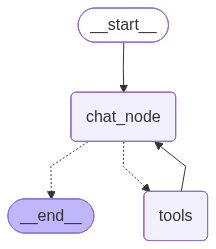

In [19]:
workflow

In [23]:
result = workflow.invoke(
    {
        "messages": [
            HumanMessage(content="use the PDF Explain decision tree in detail.")
        ]
    }
)

In [24]:
print(result['messages'][-1].content)

A decision tree is a model used for classification and regression tasks in machine learning. It represents decisions and their possible consequences, forming a tree-like structure. Here’s a detailed explanation of decision trees based on the information extracted:

### Structure of a Decision Tree
- **Nodes**: Each node represents a feature (attribute), which holds a test (or question) about that feature.
- **Edges**: Edges connect the nodes, leading to the next question based on the answer given in the previous node.
- **Leaves**: Terminal nodes (or leaves) contain the final output—either a class label in classification tasks or a regression value.

### Functioning of a Decision Tree
1. **Tree Construction**: Building a decision tree involves recursively splitting the dataset into subsets based on features. Each split is determined by asking a question that maximizes the separation of classes or minimizes the error in predictions.
2. **Partitioning**: The algorithm creates partitions 